<a href="https://www.kaggle.com/code/indyistiqamah/yolo26-spd?scriptVersionId=347369159" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# **Deteksi Cacat Permukaan Pada Jeruk Keprok Menggunakan Yolo26-SPD** 

In [1]:
# ============================================================
# INSTALL ROBOFLOW
# ============================================================
!pip install -q roboflow

# ============================================================
# CLONE REPOSITORY YOLO26-SPD
# ============================================================
%cd /kaggle/working

!rm -rf ultralyticsYolo26
!git clone https://github.com/inndyis/ultralyticsYolo26.git

%cd /kaggle/working/ultralyticsYolo26

# Hapus ultralytics bawaan, lalu install repo custom
!pip uninstall ultralytics -y
!pip install -e .

# Cek apakah ultralytics yang aktif berasal dari repo custom
import ultralytics
print("Ultralytics path:", ultralytics.__file__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 80.1 MB/s eta 0:00:00
/kaggle/working
Cloning into 'ultralyticsYolo26'...
remote: Enumerating objects: 53267, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 53267 (delta 12), reused 8 (delta 8), pack-reused 53251 (from 2)
Receiving objects: 100% (53267/53267), 33.74 MiB | 29.46 MiB/s, done.
Resolving deltas: 100% (38983/38983), done.
/kaggle/working/ultralyticsYolo26
Obtaining file:///kaggle/working/ultralyticsYolo26
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics

In [2]:
# ============================================================
# DOWNLOAD DATASET DARI ROBOFLOW
# ============================================================

from roboflow import Roboflow
from pathlib import Path

rf = Roboflow(api_key="Os0LrSFQLDcLOoBna47Q")

project = rf.workspace("indys-workspace").project("deteksi-cacat-permukaan-jeruk")
version = project.version(3)

dataset = version.download("yolo26")

dataset_path = Path(dataset.location)
data_yaml = str(dataset_path / "data.yaml")

print("Dataset location:", dataset_path)
print("Data YAML:", data_yaml)

print("\nIsi data.yaml:")
print(open(data_yaml).read())

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Deteksi-Cacat-Permukaan-Jeruk-3 in yolo26:: 100%|██████████| 7625/7625 [00:00<00:00, 12095.90it/s]

Dataset location: /kaggle/working/ultralyticsYolo26/Deteksi-Cacat-Permukaan-Jeruk-3
Data YAML: /kaggle/working/ultralyticsYolo26/Deteksi-Cacat-Permukaan-Jeruk-3/data.yaml

Isi data.yaml:
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['Cacat', 'Normal']

roboflow:
  workspace: indys-workspace
  project: deteksi-cacat-permukaan-jeruk
  version: 3
  license: CC BY 4.0
  url: https://universe.roboflow.com/indys-workspace/deteksi-cacat-permukaan-jeruk/dataset/3


In [3]:
# ============================================================
# BUAT data_fixed.yaml
# ============================================================

import yaml
from pathlib import Path

dataset_path = Path(dataset.location)
original_yaml = dataset_path / "data.yaml"

with open(original_yaml, "r") as f:
    old_yaml = yaml.safe_load(f)

train_img = dataset_path / "train" / "images"
val_img = dataset_path / "valid" / "images"
test_img = dataset_path / "test" / "images"

if not train_img.exists():
    raise FileNotFoundError(f"Folder train/images tidak ditemukan: {train_img}")

if not val_img.exists():
    raise FileNotFoundError(f"Folder valid/images tidak ditemukan: {val_img}")

if not test_img.exists():
    print("Folder test/images tidak ditemukan. Testing akan memakai valid/images.")
    test_img = val_img

data_fixed = {
    "train": str(train_img),
    "val": str(val_img),
    "test": str(test_img),
    "nc": old_yaml.get("nc", 2),
    "names": old_yaml.get("names", ["Cacat", "Normal"])
}

fixed_yaml_path = "/kaggle/working/data_fixed.yaml"

with open(fixed_yaml_path, "w") as f:
    yaml.dump(data_fixed, f, sort_keys=False)

print("Isi data_fixed.yaml:")
print(open(fixed_yaml_path).read())

Isi data_fixed.yaml:
train: /kaggle/working/ultralyticsYolo26/Deteksi-Cacat-Permukaan-Jeruk-3/train/images
val: /kaggle/working/ultralyticsYolo26/Deteksi-Cacat-Permukaan-Jeruk-3/valid/images
test: /kaggle/working/ultralyticsYolo26/Deteksi-Cacat-Permukaan-Jeruk-3/test/images
nc: 2
names:
- Cacat
- Normal



In [4]:
# ============================================================
# CEK JUMLAH GAMBAR DAN LABEL
# ============================================================

from pathlib import Path

print("Cek jumlah gambar dan label:")

for split in ["train", "valid", "test"]:
    img_dir = dataset_path / split / "images"
    label_dir = dataset_path / split / "labels"

    images = []
    labels = []

    if img_dir.exists():
        images = (
            list(img_dir.glob("*.jpg")) +
            list(img_dir.glob("*.jpeg")) +
            list(img_dir.glob("*.png"))
        )

    if label_dir.exists():
        labels = list(label_dir.glob("*.txt"))

    print(f"{split} images:", len(images))
    print(f"{split} labels:", len(labels))

Cek jumlah gambar dan label:
train images: 3114
train labels: 3114
valid images: 363
valid labels: 363
test images: 333
test labels: 333


**Clone Model Yolo26 dari Github**

In [5]:
# ============================================================
# CEK GPU
# ============================================================


import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    device = 0
else:
    print("GPU belum aktif. Training akan berjalan di CPU.")
    device = "cpu"

Torch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 2
GPU: Tesla T4


In [6]:
# ============================================================
# CEK MODEL
# ============================================================

from ultralytics import YOLO

model_yaml = "/kaggle/working/ultralyticsYolo26/ultralytics/cfg/models/26/yolo26n-spd.yaml"

model = YOLO(model_yaml)
model.info(detailed=True)

layer                                    name                type  gradient  parameters               shape        mu     sigma
    0                     model.0.conv.weight              Conv2d      True         432       [16, 3, 3, 3]   -0.0029     0.114        float32
    1                       model.0.bn.weight         BatchNorm2d      True          16                [16]         1         0        float32
    1                         model.0.bn.bias         BatchNorm2d      True          16                [16]         0         0        float32
    2                             model.0.act                SiLU     False           0                  []         -         -              -
    3                             model.1.spd        SpaceToDepth     False           0                  []         -         -              -
    4                model.1.conv.conv.weight              Conv2d      True       18432      [32, 64, 3, 3] -9.74e-05    0.0241        float32
    5         

(263, 3139064, 3139064, 9.6557312)

# Training Model

In [7]:
# ============================================================
# TRAINING MODEL YOLO26-SPD
# ============================================================ 

from ultralytics import YOLO
import torch
import os

os.environ["WANDB_DISABLED"] = "true"

device = 0 if torch.cuda.is_available() else "cpu"

model_yaml = "/kaggle/working/ultralyticsYolo26/ultralytics/cfg/models/26/yolo26n-spd.yaml"

model = YOLO(model_yaml)

results = model.train(
    data=fixed_yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=device,
    workers=2,
    project="/kaggle/working/yolo26spd_training",
    name="yolo26n_spd_cacat_jeruk",
    pretrained=False,
    patience=30,
    plots=True,
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.140 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/ultralyticsYolo26/ultralytics/cfg/models/26/yolo

In [8]:
# ============================================================   
# AMBIL best.pt
# ============================================================ 

from pathlib import Path

best_model_path = "/kaggle/working/yolo26spd_training/yolo26n_spd_cacat_jeruk/weights/best.pt"

if not Path(best_model_path).exists():
    best_files = list(Path("/kaggle/working").rglob("best.pt"))
    print("Daftar best.pt yang ditemukan:")
    for i, p in enumerate(best_files):
        print(i, p)

    best_model_path = str(best_files[-1])

print("Best model digunakan:")
print(best_model_path)

Best model digunakan:
/kaggle/working/yolo26spd_training/yolo26n_spd_cacat_jeruk/weights/best.pt


# Validasi

In [9]:
# ============================================================
# VALIDASI MODEL
# ============================================================ 

from ultralytics import YOLO
import torch

device = 0 if torch.cuda.is_available() else "cpu"

best_model = YOLO(best_model_path)

val_metrics = best_model.val(
    data=fixed_yaml_path,
    split="val",
    imgsz=640,
    batch=16,
    device=device,
    plots=True,
    save_json=True,
    project="/kaggle/working/yolo26spd_validation",
    name="val_result",
    exist_ok=True
)

print("Validasi selesai.")
print(val_metrics)

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n-spd summary (fused): 125 layers, 2,942,010 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 567.4±119.7 MB/s, size: 15.2 KB)
val: Scanning /kaggle/working/ultralyticsYolo26/Deteksi-Cacat-Permukaan-Jeruk-3/valid/labels.cache... 363 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 363/363 152.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 5.8it/s 4.0s
                   all        363        363      0.879      0.914      0.956      0.934
                 Cacat        193        193      0.894      0.917      0.956      0.925
                Normal        170        170      0.864      0.912      0.956      0.942
Speed: 1.5ms preprocess, 4.9ms inference, 0.0ms loss, 0.4ms postprocess per image
Saving /kaggle/working/yolo26spd_validation/val_result/predictions.json...
Results saved 

# Testing

In [10]:
# ============================================================
# TESTING MODEL
# ============================================================ 

test_metrics = best_model.val(
    data=fixed_yaml_path,
    split="test",
    imgsz=640,
    batch=16,
    device=device,
    plots=True,
    save_json=True,
    project="/kaggle/working/yolo26spd_testing",
    name="test_result",
    exist_ok=True
)

print("Testing selesai.")
print(test_metrics)

Ultralytics 8.4.52 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 574.5±192.6 MB/s, size: 16.2 KB)
val: Scanning /kaggle/working/ultralyticsYolo26/Deteksi-Cacat-Permukaan-Jeruk-3/test/labels... 333 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 333/333 1.3Kit/s 0.3s
val: New cache created: /kaggle/working/ultralyticsYolo26/Deteksi-Cacat-Permukaan-Jeruk-3/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 5.5it/s 3.8s
                   all        333        333      0.912      0.922      0.976      0.935
                 Cacat        169        169      0.913      0.929      0.977       0.92
                Normal        164        164      0.911      0.915      0.975       0.95
Speed: 1.6ms preprocess, 5.1ms inference, 0.0ms loss, 0.3ms postprocess per image
Saving /kaggle/working/yolo26spd_testing/test_result/predictions.json...
Resu

In [11]:
# ============================================================
# PREDIKSI GAMBAR TEST
# ============================================================ 

test_images_path = str(test_img)

pred_results = best_model.predict(
    source=test_images_path,
    imgsz=640,
    conf=0.50,
    iou=0.30,
    device=device,
    save=True,
    save_txt=True,
    save_conf=True,
    project="/kaggle/working/yolo26spd_prediction",
    name="prediction_result",
    exist_ok=True
)

print("Prediksi selesai.")
print("Hasil prediksi tersimpan di:")
print("/kaggle/working/yolo26spd_prediction/prediction_result")


image 1/333 /kaggle/working/ultralyticsYolo26/Deteksi-Cacat-Permukaan-Jeruk-3/test/images/b-175-_jpg.rf.4f5cd1c91c50b38b06ff48f422a04b76.jpg: 640x640 1 Cacat, 9.7ms
image 2/333 /kaggle/working/ultralyticsYolo26/Deteksi-Cacat-Permukaan-Jeruk-3/test/images/c-149-_jpg.rf.0aaccecab4c3d200e871ea65ce1845df.jpg: 640x640 1 Cacat, 9.7ms
image 3/333 /kaggle/working/ultralyticsYolo26/Deteksi-Cacat-Permukaan-Jeruk-3/test/images/c-162-_jpg.rf.35bf33934f6a086adc442d94200e9ccd.jpg: 640x640 2 Cacats, 9.7ms
image 4/333 /kaggle/working/ultralyticsYolo26/Deteksi-Cacat-Permukaan-Jeruk-3/test/images/conveyor_frame_00000_jpg.rf.5ecd2033b445f631dab37c42d147e1a4.jpg: 640x640 1 Normal, 10.3ms
image 5/333 /kaggle/working/ultralyticsYolo26/Deteksi-Cacat-Permukaan-Jeruk-3/test/images/conveyor_frame_00001_jpg.rf.70f7dd16f9702873db46a7b52138dfa8.jpg: 640x640 1 Normal, 9.7ms
image 6/333 /kaggle/working/ultralyticsYolo26/Deteksi-Cacat-Permukaan-Jeruk-3/test/images/conveyor_frame_00001_jpg.rf.b83445188668e307be70e61a

Jumlah gambar hasil prediksi: 333


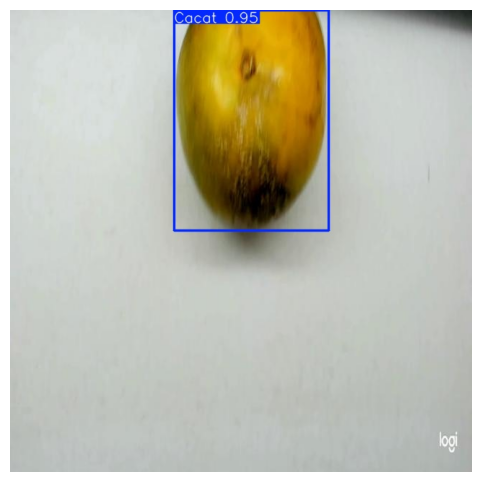

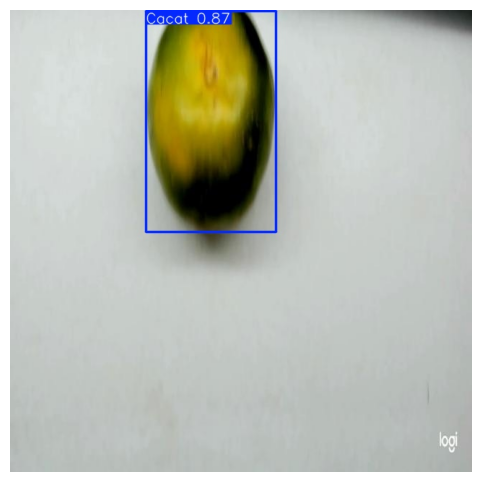

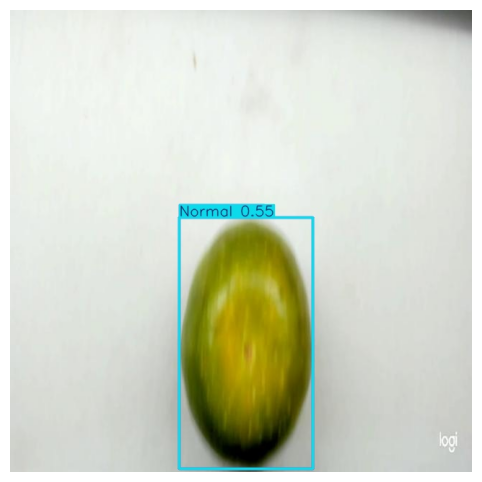

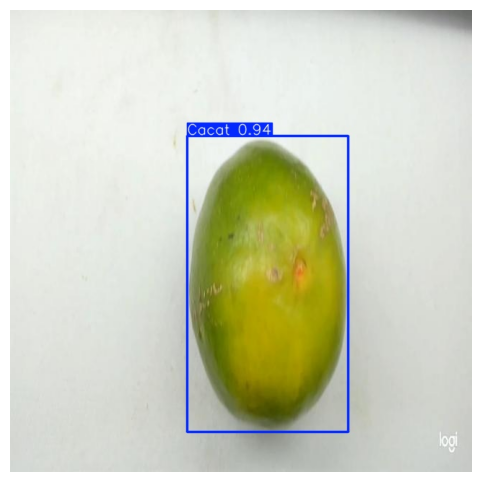

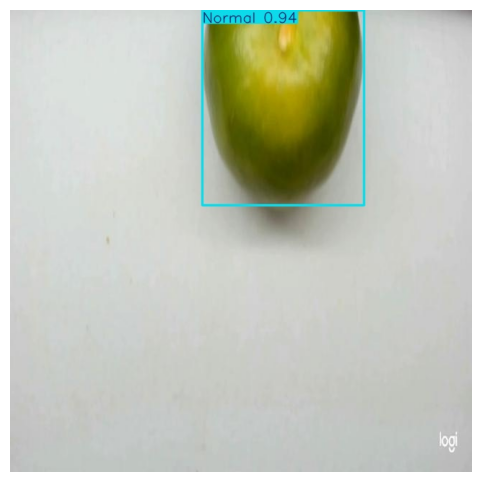

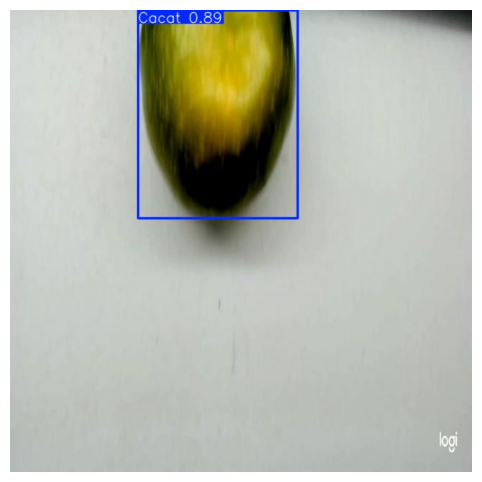

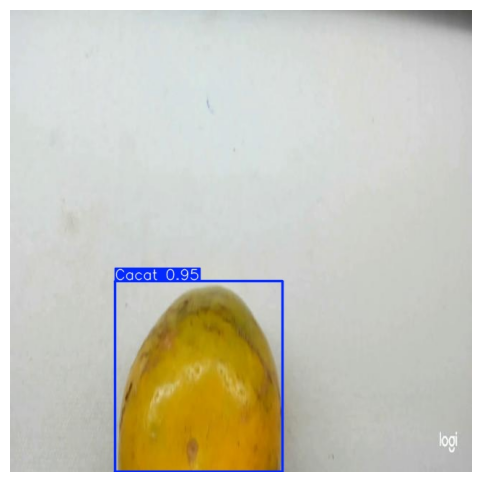

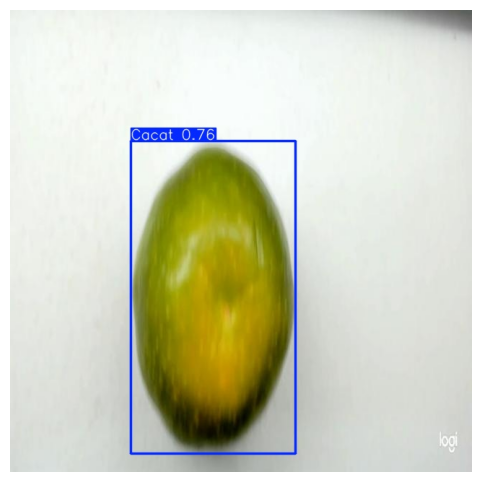

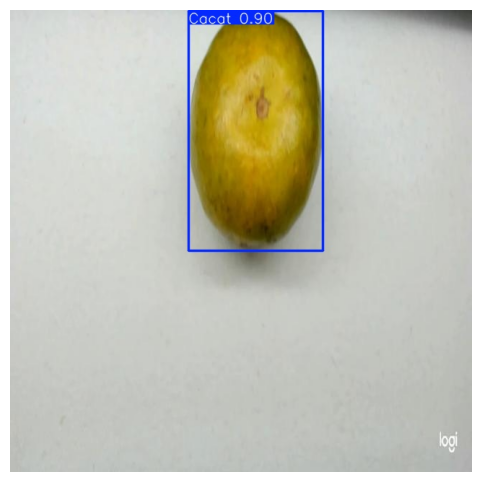

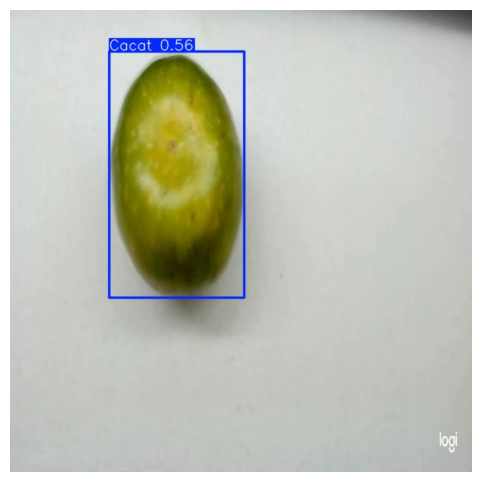

In [12]:
# ============================================================
# TAMPILKAN HASIL PREDIKSI 
# ============================================================ 
import glob
import cv2
import matplotlib.pyplot as plt

pred_folder = "/kaggle/working/yolo26spd_prediction/prediction_result"

pred_images = (
    glob.glob(pred_folder + "/*.jpg") +
    glob.glob(pred_folder + "/*.jpeg") +
    glob.glob(pred_folder + "/*.png")
)

print("Jumlah gambar hasil prediksi:", len(pred_images))

for img_path in pred_images[:10]:
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

confusion_matrix.png


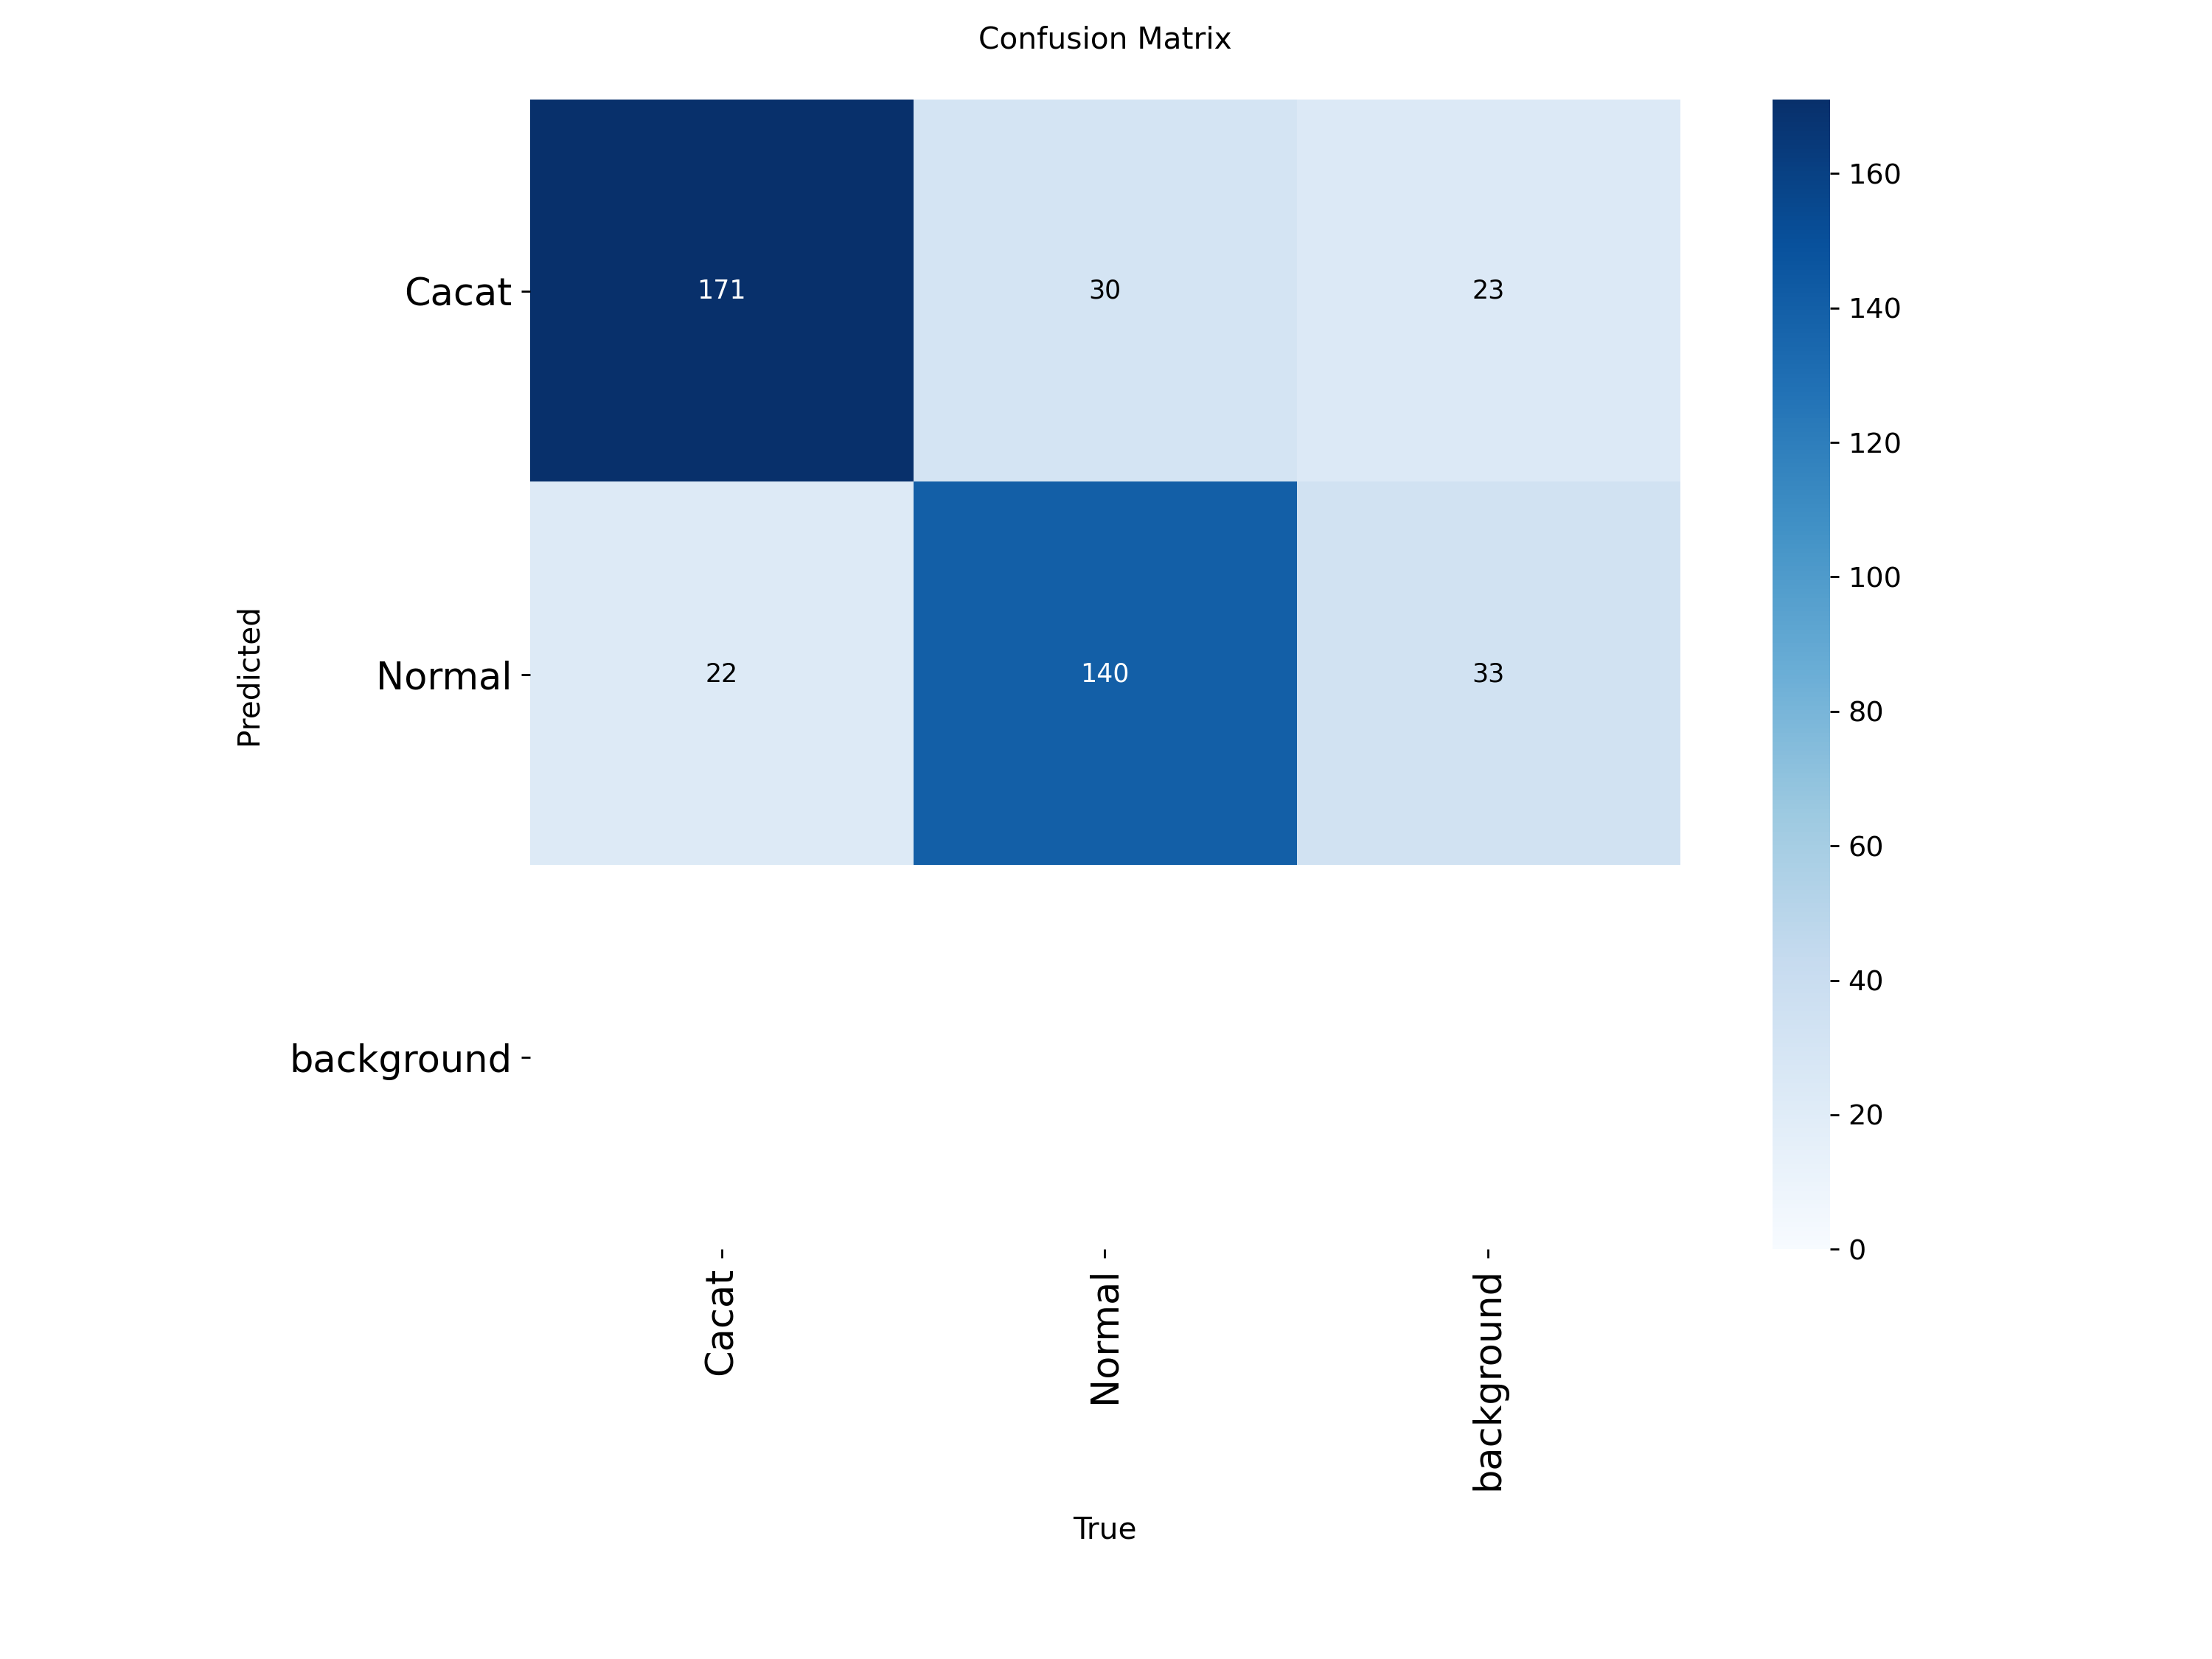

In [13]:
# ============================================================
# Tampilkan Confusion Matrix dan Kurva Evaluasi 
# VALIDASI
# ============================================================

from IPython.display import Image, display
from pathlib import Path

val_result_dir = Path("/kaggle/working/yolo26spd_validation/val_result")

for file_name in [
    "confusion_matrix.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "PR_curve.png"
]:
    file_path = val_result_dir / file_name
    if file_path.exists():
        print(file_name)
        display(Image(filename=str(file_path)))

confusion_matrix.png


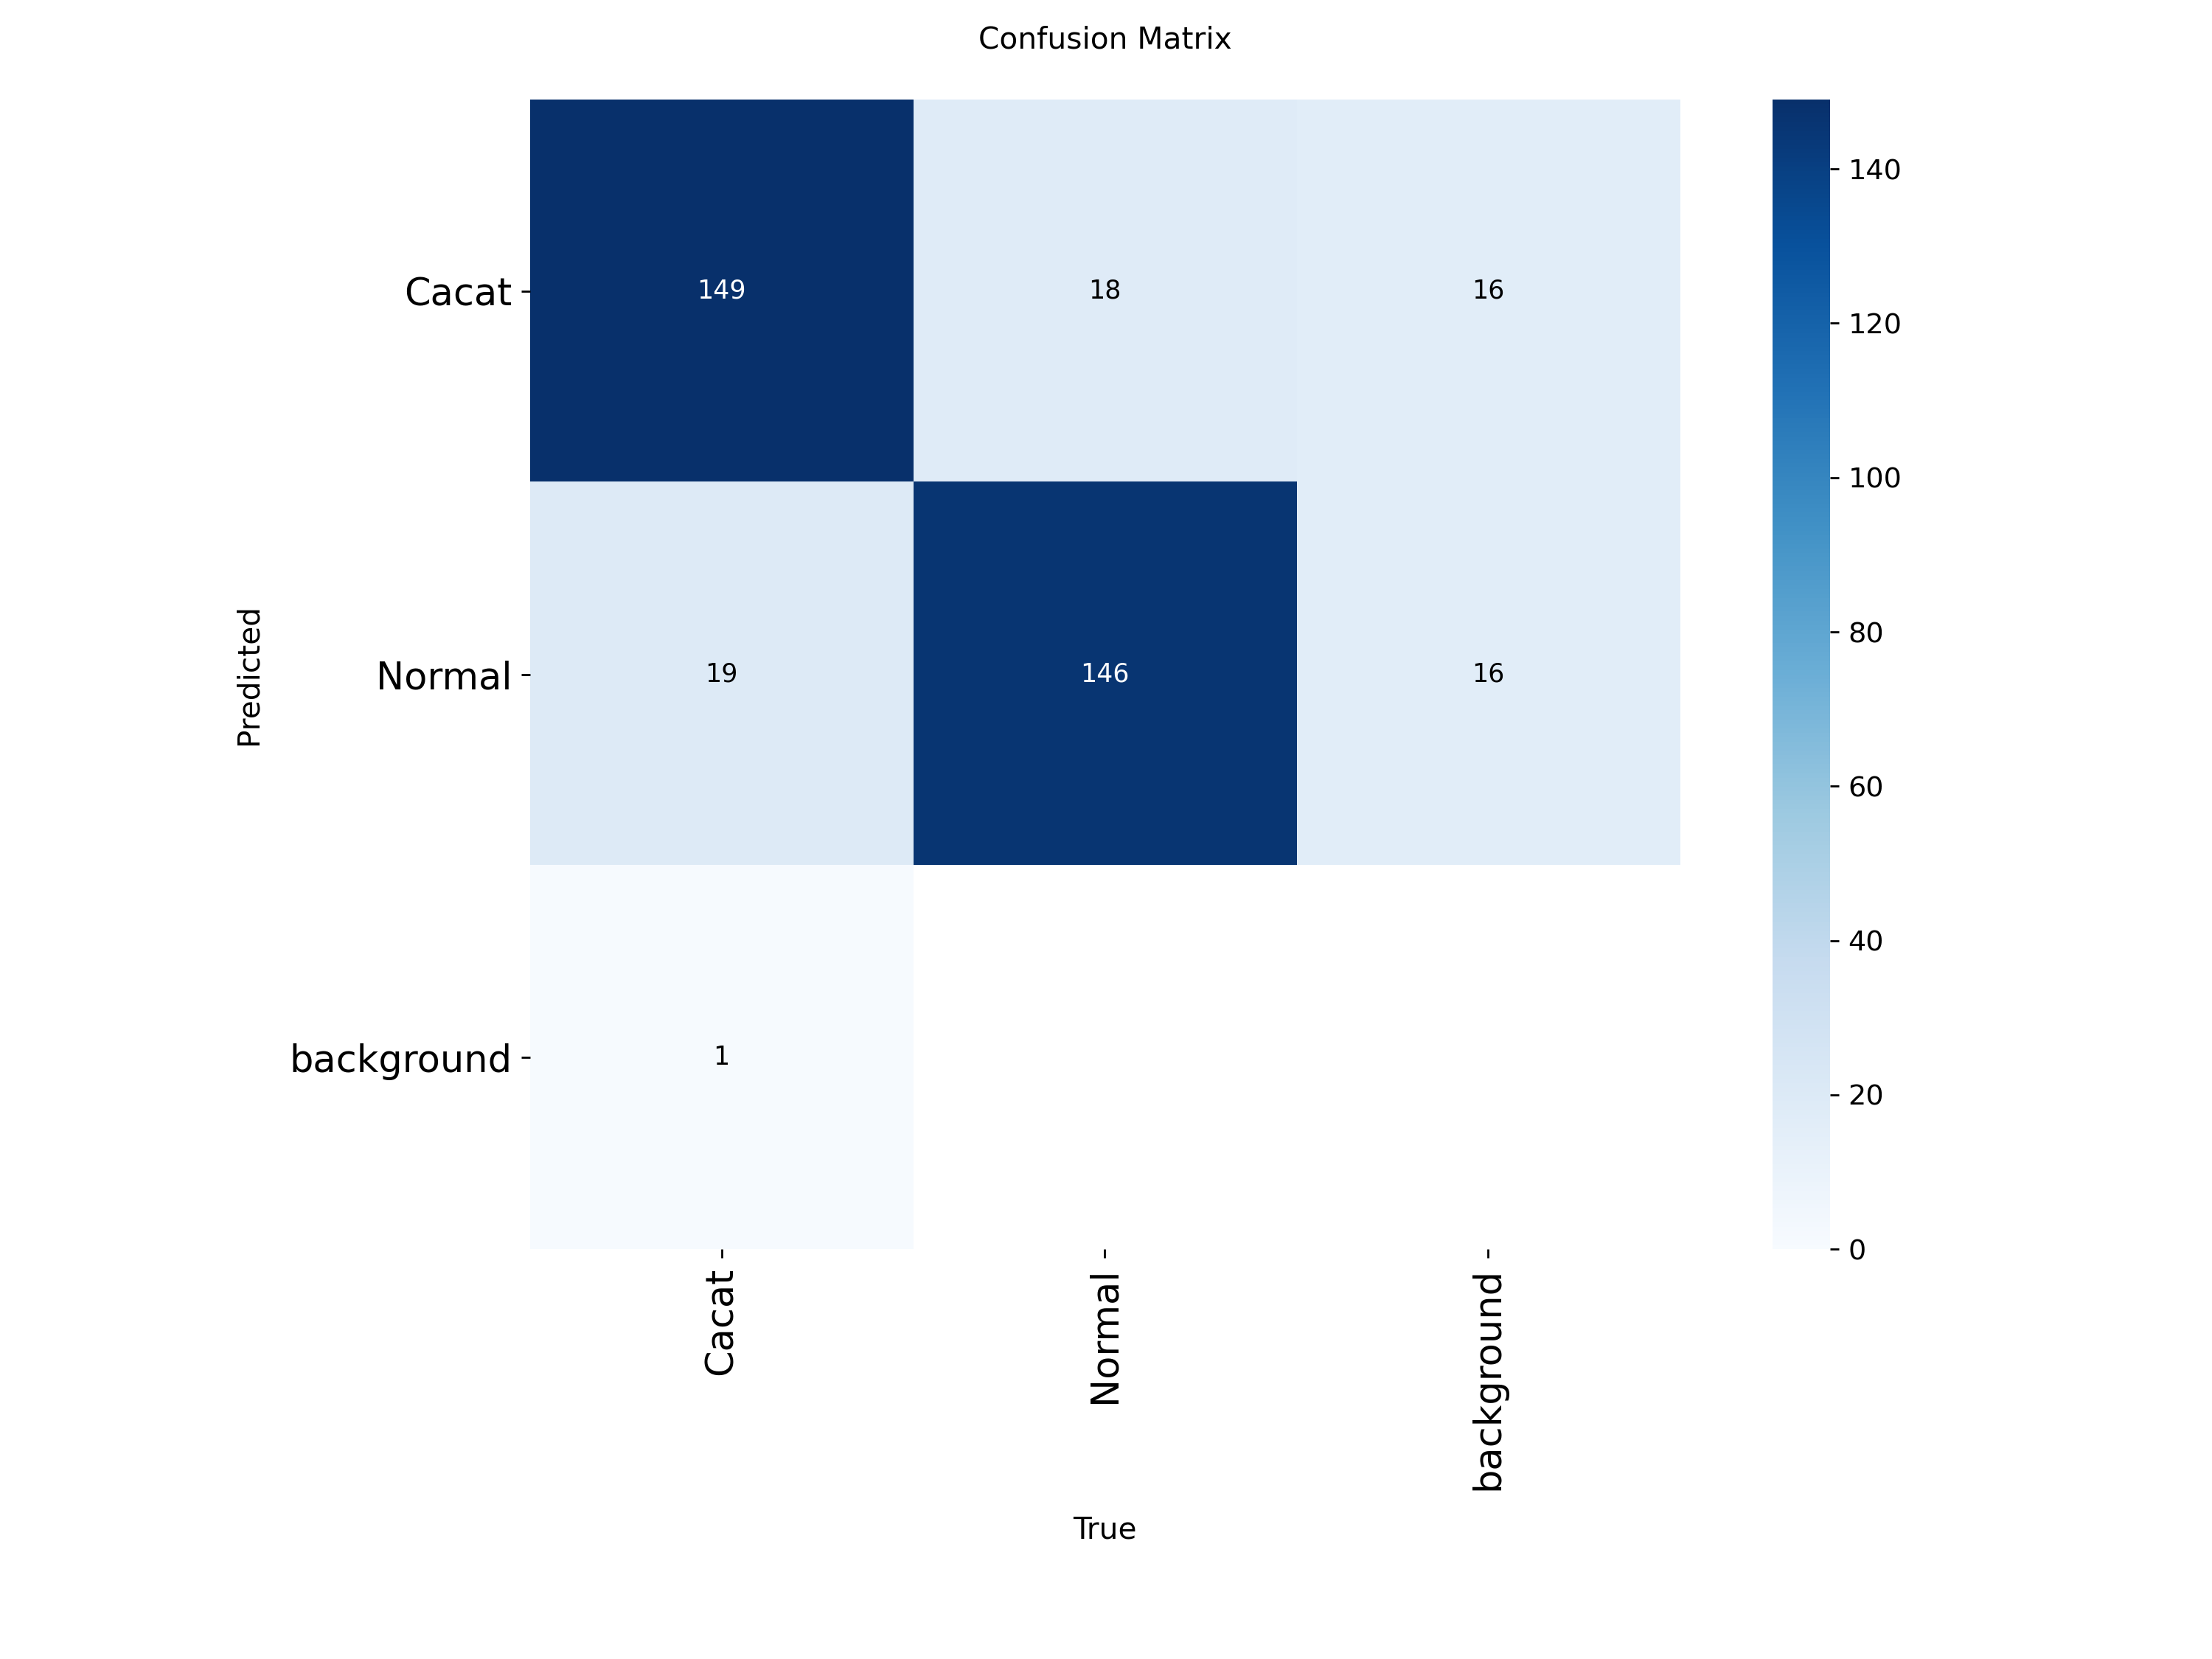

In [14]:
# ============================================================
# Tampilkan Confusion Matrix dan Kurva Evaluasi 
# TESTING
# ============================================================

from IPython.display import Image, display
from pathlib import Path

test_result_dir = Path("/kaggle/working/yolo26spd_testing/test_result")

for file_name in [
    "confusion_matrix.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "PR_curve.png"
]:
    file_path = test_result_dir / file_name
    if file_path.exists():
        print(file_name)
        display(Image(filename=str(file_path)))

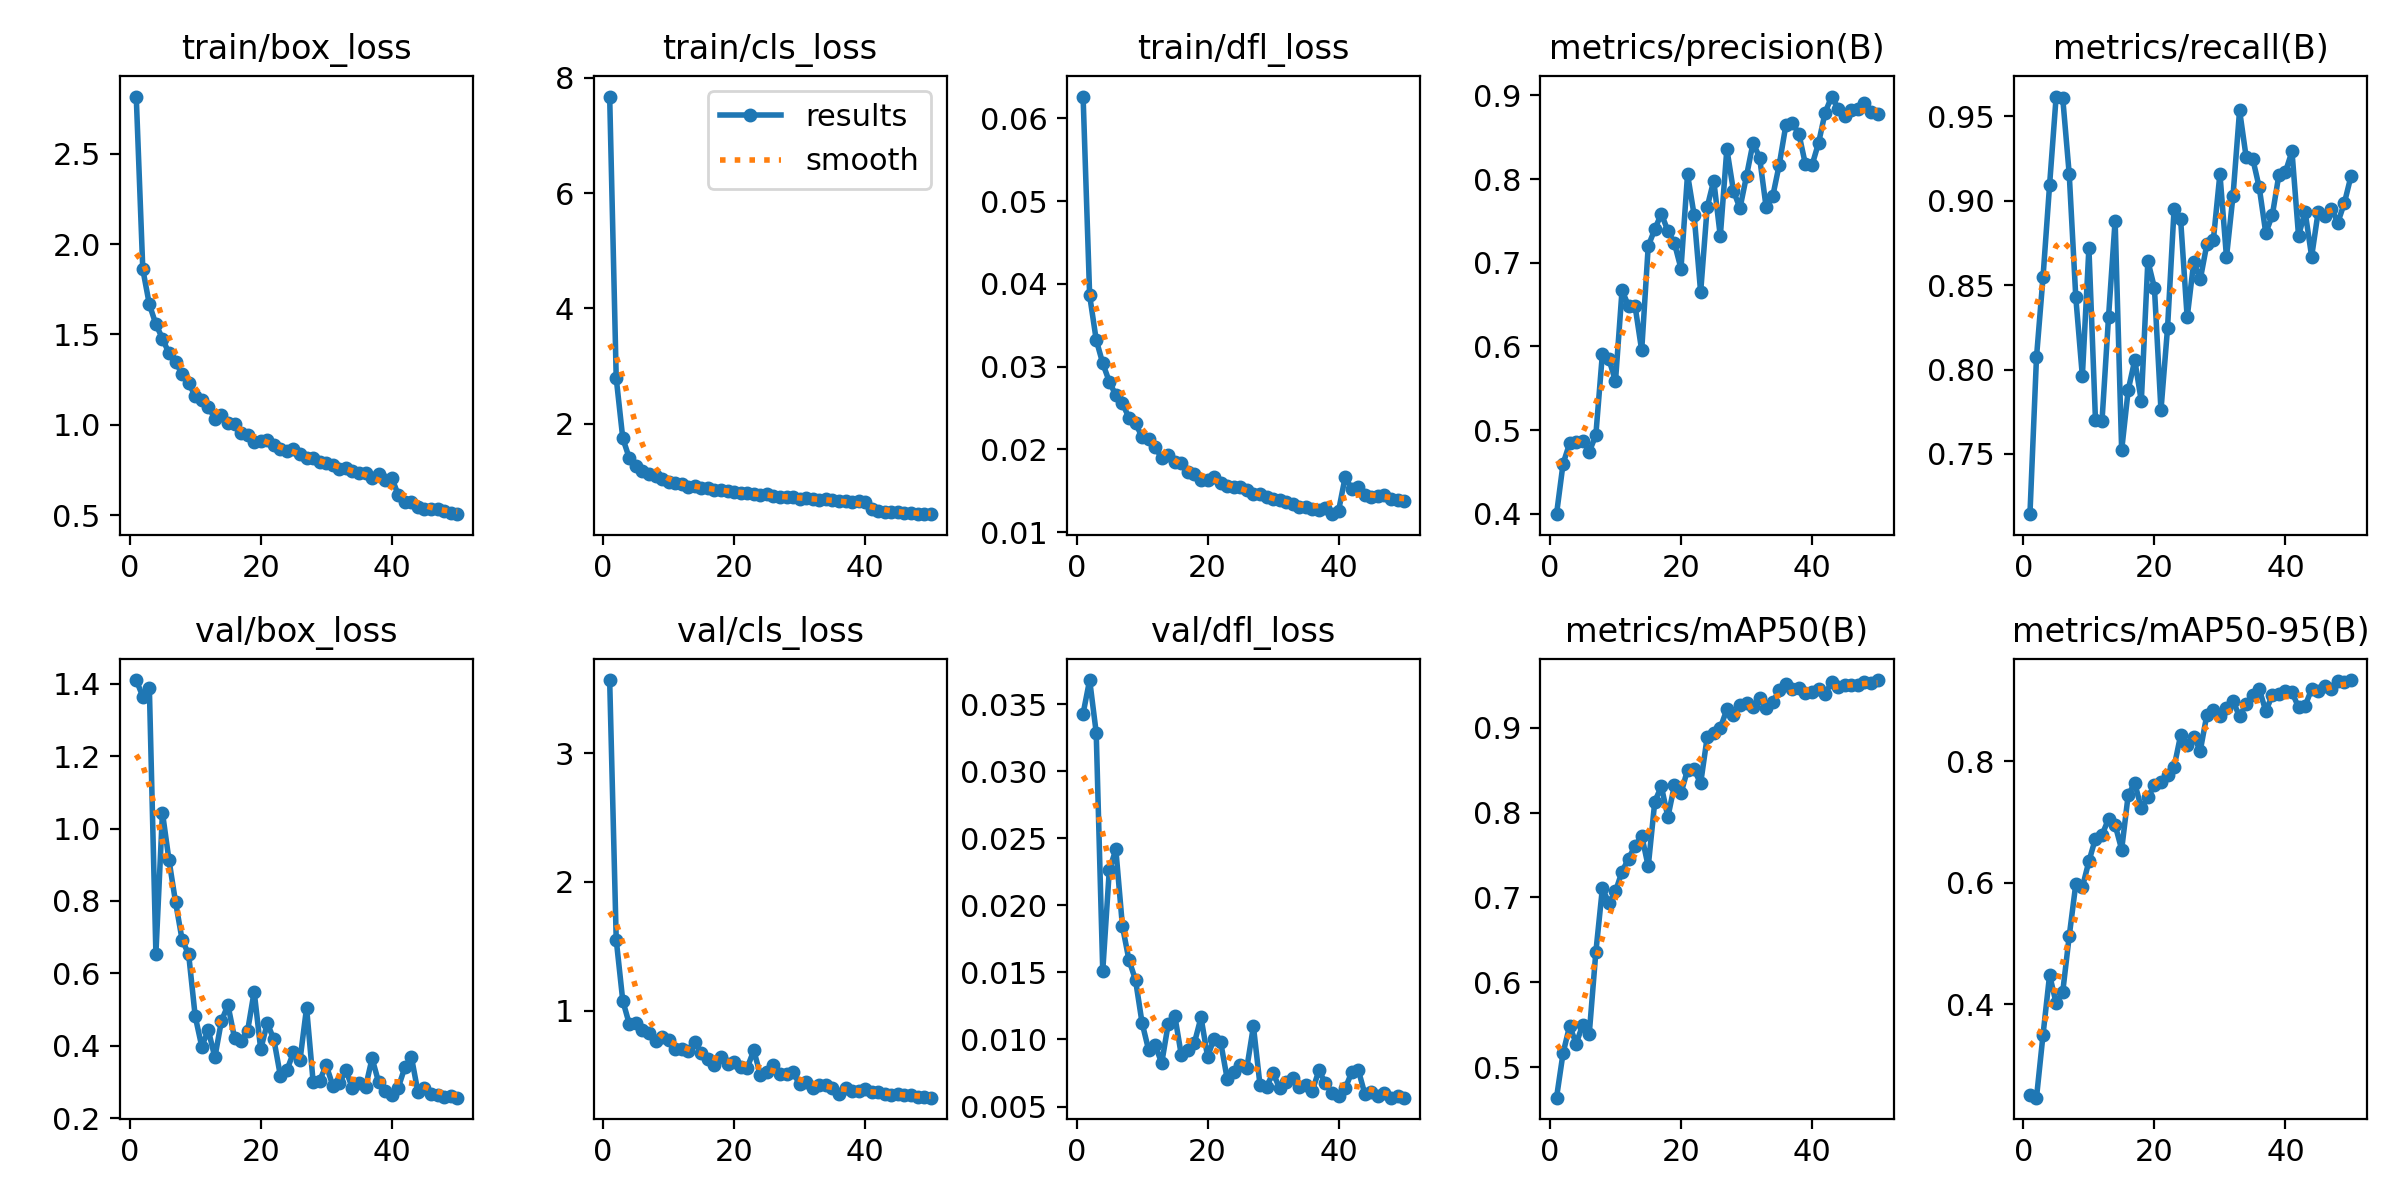

In [15]:
from IPython.display import Image, display
from pathlib import Path

result_dir = Path("/kaggle/working/yolo26spd_training/yolo26n_spd_cacat_jeruk")

display(Image(filename=str(result_dir / "results.png")))

In [16]:
import shutil
from pathlib import Path
from IPython.display import FileLink, display

# ============================
# CARI BEST.PT
# ============================
best_files = list(Path("/kaggle/working").rglob("best.pt"))

if len(best_files) == 0:
    raise FileNotFoundError("best.pt tidak ditemukan. Pastikan training sudah selesai.")

best_model_path = best_files[-1]
run_dir = best_model_path.parent.parent

print("Best model:", best_model_path)
print("Run directory:", run_dir)

# ============================
# ZIP FOLDER TRAINING
# ============================
training_zip_name = "/kaggle/working/YOLO26_SPD_Modified_Training_Output"
shutil.make_archive(training_zip_name, 'zip', run_dir)

training_zip_path = training_zip_name + ".zip"
print("Training output ZIP:", training_zip_path)
display(FileLink(training_zip_path))

# ============================
# ZIP FOLDER VALIDATION JIKA ADA
# ============================
val_dir = Path("/kaggle/working/yolo26spd_validation/val_result")

if val_dir.exists():
    val_zip_name = "/kaggle/working/YOLO26_SPD_Modified_Validation_Output"
    shutil.make_archive(val_zip_name, 'zip', val_dir)

    val_zip_path = val_zip_name + ".zip"
    print("Validation output ZIP:", val_zip_path)
    display(FileLink(val_zip_path))
else:
    print("Folder validasi tidak ditemukan.")

# ============================
# ZIP FOLDER TESTING JIKA ADA
# ============================
test_dir = Path("/kaggle/working/yolo26spd_testing/test_result")

if test_dir.exists():
    test_zip_name = "/kaggle/working/YOLO26_SPD_Modified_Testing_Output"
    shutil.make_archive(test_zip_name, 'zip', test_dir)

    test_zip_path = test_zip_name + ".zip"
    print("Testing output ZIP:", test_zip_path)
    display(FileLink(test_zip_path))
else:
    print("Folder testing tidak ditemukan.")

# ============================
# ZIP FOLDER PREDICTION JIKA ADA
# ============================
pred_dir = Path("/kaggle/working/yolo26spd_prediction/prediction_result")

if pred_dir.exists():
    pred_zip_name = "/kaggle/working/YOLO26_SPD_Modified_Prediction_Output"
    shutil.make_archive(pred_zip_name, 'zip', pred_dir)

    pred_zip_path = pred_zip_name + ".zip"
    print("Prediction output ZIP:", pred_zip_path)
    display(FileLink(pred_zip_path))
else:
    print("Folder prediksi tidak ditemukan.")

Best model: /kaggle/working/yolo26spd_training/yolo26n_spd_cacat_jeruk/weights/best.pt
Run directory: /kaggle/working/yolo26spd_training/yolo26n_spd_cacat_jeruk
Training output ZIP: /kaggle/working/YOLO26_SPD_Modified_Training_Output.zip


/kaggle/working/YOLO26_SPD_Modified_Training_Output.zip

Validation output ZIP: /kaggle/working/YOLO26_SPD_Modified_Validation_Output.zip


/kaggle/working/YOLO26_SPD_Modified_Validation_Output.zip

Testing output ZIP: /kaggle/working/YOLO26_SPD_Modified_Testing_Output.zip


/kaggle/working/YOLO26_SPD_Modified_Testing_Output.zip

Prediction output ZIP: /kaggle/working/YOLO26_SPD_Modified_Prediction_Output.zip


/kaggle/working/YOLO26_SPD_Modified_Prediction_Output.zip

In [17]:
#!pip install roboflow

# from roboflow import Roboflow
# rf = Roboflow(api_key="Os0LrSFQLDcLOoBna47Q")
# project = rf.workspace("indys-workspace").project("deteksi-cacat-permukaan-jeruk")
# version = project.version(3)
# dataset = version.download("yolo26")
                

In [18]:
# !git clone https://github.com/inndyis/ultralyticsYolo26.git

# %cd /kaggle/working/ultralyticsYolo26

# import ultralytics
# print(ultralytics.__file__)

In [19]:
# !git clone https://github.com/inndyis/ultralyticsYolo26.git

# %cd /kaggle/working/ultralyticsYolo26

# !pip uninstall ultralytics -y
# !pip install -e .

# import ultralytics
# print(ultralytics.__file__) 

# from ultralytics import YOLO 


# model = YOLO("/kaggle/working/ultralyticsYolo26/ultralytics/cfg/models/26/yolo26n-spd.yaml")
# model.info(detailed=True)

In [20]:
# from ultralytics import YOLO

# model_yaml = "/kaggle/working/ultralyticsYolo26/ultralytics/cfg/models/26/yolo26n-spd.yaml"
# data_yaml = "/kaggle/working/Deteksi-Cacat-Permukaan-Jeruk-3/data.yaml"

# model = YOLO(model_yaml)

# results = model.train(
#    data=data_yaml,
#    epochs=100
# )